# Prédiction du genre de l'auteur

Ce notebook utilise `features.csv` pour prédire le genre de l'auteur.

- Première partie : **features personnages uniquement**.
- Deuxième partie : **features personnages + métadonnées**.

Pour chaque jeu de variables, on :
- fait une validation croisée (5-fold) avec 3 modèles,
- ré-estime les mêmes modèles avec pondérations de classes,
- puis on choisit un modèle (ici : Gradient Boosting pondéré) pour analyser
  l'effet du seuil de décision sur la classe *female*.

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.base import clone

import matplotlib.pyplot as plt
import seaborn as sns

# Style des graphiques
sns.set(style="whitegrid")
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11

RANDOM_STATE = 42

KeyboardInterrupt: 

## Chargement des données

In [ ]:
# Chargement des données de features
features_path = Path("features.csv")
df = pd.read_csv(features_path)


# On garde uniquement les livres avec auteur male/female
df = df[df["gender"].isin(["male", "female"])].copy()
df["gender"] = df["gender"].astype(str)
print("Shape après filtrage male/female :", df.shape)

# On enlève l'identifiant des features
id_cols = [c for c in ["book_id"] if c in df.columns]

# Colonnes de features candidates
feature_cols = [c for c in df.columns if c not in id_cols + ["gender"]]
print("Nombre total de features :", len(feature_cols))

# Séparation des features personnages vs meta
meta_prefixes = ["meta_"]
meta_explicit = ["meta_year", "meta_canon"]

meta_cols = [
    c for c in feature_cols
    if any(c.startswith(p) for p in meta_prefixes) or c in meta_explicit
]
char_cols = [c for c in feature_cols if c not in meta_cols]

print("Features personnages :", len(char_cols))
print("Features meta :", len(meta_cols))

# DataFrames pour la suite
X_char = df[char_cols]
X_full = df[char_cols + meta_cols]
y = df["gender"]

# --- garder uniquement les colonnes numériques (pour SimpleImputer(mean)) ---
def keep_numeric_only(X: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    return X[numeric_cols].copy()

X_char = keep_numeric_only(X_char)
X_full = keep_numeric_only(X_full)

print("X_char numeric shape :", X_char.shape)
print("X_full numeric shape :", X_full.shape)

Shape après filtrage male/female : (2917, 483)
Nombre total de features : 481
Features personnages : 454
Features meta : 27
X_char numeric shape : (2917, 453)
X_full numeric shape : (2917, 455)


## Fonctions utilitaires

- `get_models(weighted)` : crée les 3 modèles, avec ou sans pondération de classes.
- `run_cv_for_models(X, y, description, weighted)` : 5-fold CV, renvoie un DataFrame
  avec accuracy et macro-F1.
- `threshold_analysis(X, y, description, weighted)` : entraîne un Gradient Boosting
  (pondéré ou non) sur un split train/test et trace des courbes
  précision/rappel en fonction du seuil sur la classe *female*.

In [ ]:
def get_models(weighted=False):
    if weighted:
        log_reg = LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")
        rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")
        gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
    else:
        log_reg = LogisticRegression(max_iter=2000, solver="lbfgs")
        rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
        gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
    return {"LogisticRegression": log_reg, "RandomForest": rf, "GradientBoosting": gb}


def compute_sample_weight(y_train):
    counts = y_train.value_counts().to_dict()
    return y_train.map(lambda c: 1.0 / counts[c]).values


def run_cv_for_models(X, y, description, weighted=False, n_splits=5):
    print("\n===", description, "===")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    models = get_models(weighted)

    results = []
    Xv, yv = X.values, y.values

    for name, base_model in models.items():
        print(f"\nModèle : {name}")
        y_true_all, y_pred_all = [], []
        first_cm_done = False

        for fold, (tr, te) in enumerate(skf.split(Xv, yv), start=1):
            Xtr, Xte = Xv[tr], Xv[te]
            ytr, yte = yv[tr], yv[te]

            imputer = SimpleImputer(strategy="mean")
            Xtr = imputer.fit_transform(Xtr)
            Xte = imputer.transform(Xte)

            model = clone(base_model)
            if weighted and isinstance(model, GradientBoostingClassifier):
                sw = compute_sample_weight(pd.Series(ytr))
                model.fit(Xtr, ytr, sample_weight=sw)
            else:
                model.fit(Xtr, ytr)

            ypred = model.predict(Xte)
            y_true_all.extend(list(yte))
            y_pred_all.extend(list(ypred))

            # first-fold confusion matrix
            if not first_cm_done:
                cm = confusion_matrix(yte, ypred, labels=["female", "male"])
                disp = ConfusionMatrixDisplay(cm, display_labels=["female", "male"])
                fig, ax = plt.subplots(figsize=(4, 4))
                disp.plot(ax=ax)
                ax.set_title(f"")
                ax.grid(False)
                plt.show()
                first_cm_done = True

        y_true_all = np.array(y_true_all)
        y_pred_all = np.array(y_pred_all)

        acc = accuracy_score(y_true_all, y_pred_all)
        macro_f1 = f1_score(y_true_all, y_pred_all, average="macro")
        prec, rec, f1, _ = precision_recall_fscore_support(y_true_all, y_pred_all, labels=["female", "male"])

        print(f"Accuracy: {acc:.3f}")
        print(f"Macro-F1: {macro_f1:.3f}")
        print(f"Female — precision {prec[0]:.3f}, recall {rec[0]:.3f}, F1 {f1[0]:.3f}")

        results.append({"model": name, "accuracy": acc, "macro_f1": macro_f1})

    return pd.DataFrame(results)


In [ ]:
def threshold_analysis(X, y, description, weighted=True, test_size=0.2, tau=0.4):
    print("\n=============================")
    print("Analyse de seuil –", description)
    print("Seuil =", tau)
    print("=============================\n")

    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
    )

    imputer = SimpleImputer(strategy="mean")
    Xtr = imputer.fit_transform(Xtr)
    Xte = imputer.transform(Xte)

    gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

    if weighted:
        sw = compute_sample_weight(ytr.reset_index(drop=True))
        gb.fit(Xtr, ytr, sample_weight=sw)
    else:
        gb.fit(Xtr, ytr)

    # probas pour la classe "female"
    class_idx = np.where(gb.classes_ == "female")[0][0]
    proba = gb.predict_proba(Xte)[:, class_idx]

    # courbes precision / recall en fonction du seuil
    y_true_bin = (yte == "female").astype(int)
    precision, recall, thresholds = precision_recall_curve(y_true_bin, proba)

    plt.figure(figsize=(6, 4))
    plt.plot(thresholds, precision[:-1], label="Précision (female)")
    plt.plot(thresholds, recall[:-1], label="Rappel (female)")
    plt.xlabel("Seuil")
    plt.ylabel("Score")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # évaluation au seuil tau
    ypred = np.where(proba >= tau, "female", "male")

    # métriques globales
    acc = accuracy_score(yte, ypred)
    macro_f1 = f1_score(yte, ypred, average="macro")

    print(f"Accuracy globale : {acc:.3f}")
    print(f"Macro-F1         : {macro_f1:.3f}\n")

    # rapport détaillé
    print("Classification report :\n")
    print(classification_report(yte, ypred, digits=3))

    # matrice de confusion
    cm = confusion_matrix(yte, ypred, labels=["female", "male"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["female", "male"])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax)
    ax.set_title(f"Matrice de confusion (τ={tau})")
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    return gb, imputer, acc, macro_f1


In [ ]:
# DataFrames pour la suite
X_char = df[char_cols]
X_full = df[char_cols + meta_cols]
y = df["gender"]

# --- garder uniquement les colonnes numériques (pour SimpleImputer(mean)) ---
def keep_numeric_only(X: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    return X[numeric_cols].copy()

X_char = keep_numeric_only(X_char)
X_full = keep_numeric_only(X_full)

print("X_char numeric shape :", X_char.shape)
print("X_full numeric shape :", X_full.shape)

X_char numeric shape : (2917, 453)
X_full numeric shape : (2917, 455)


# Partie 1 – Prédiction avec features personnages uniquement

Dans cette section, on utilise uniquement les variables dérivées des personnages
(`X_char`).


=== Personnages ===

Modèle : LogisticRegression


C:\Users\arnod\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


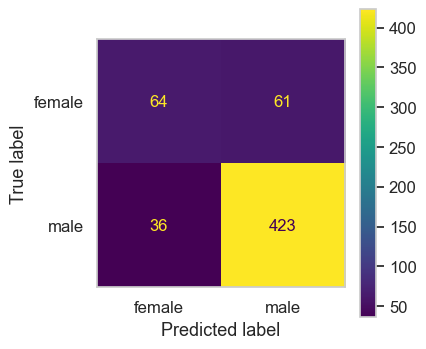

Accuracy: 0.828
Macro-F1: 0.707
Female — precision 0.646, recall 0.435, F1 0.520

Modèle : RandomForest


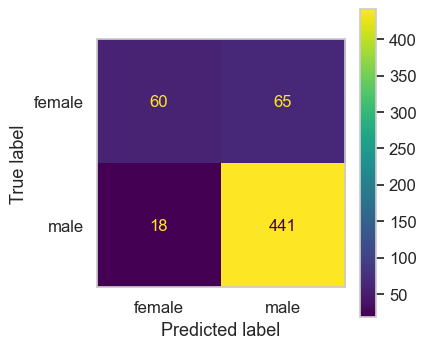

Accuracy: 0.847
Macro-F1: 0.731
Female — precision 0.743, recall 0.442, F1 0.555

Modèle : GradientBoosting


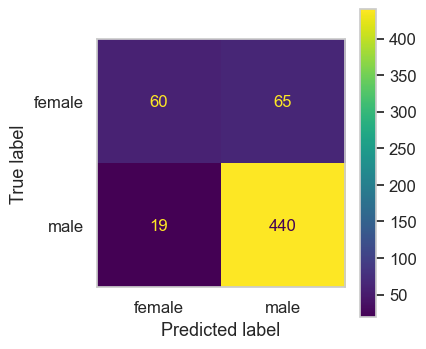

Accuracy: 0.845
Macro-F1: 0.734
Female — precision 0.716, recall 0.463, F1 0.563


,model,accuracy,macro_f1
0,LogisticRegression,0.827563,0.707252
1,RandomForest,0.847446,0.731259
2,GradientBoosting,0.845389,0.734330


In [ ]:
# Validation croisée (5-fold) – modèles NON pondérés
cv_results_char_unw = run_cv_for_models(
    X_char, y,
    description="Personnages",
    weighted=False,
    n_splits=5,
)
cv_results_char_unw


=== Personnages seuls ===

Modèle : LogisticRegression


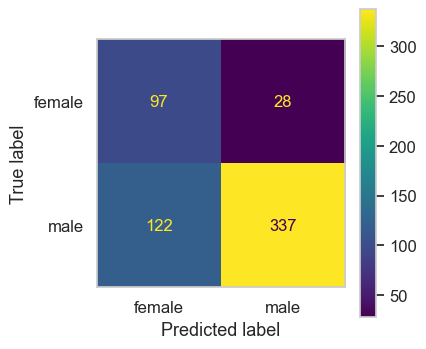

C:\Users\arnod\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.740
Macro-F1: 0.685
Female — precision 0.438, recall 0.751, F1 0.553

Modèle : RandomForest


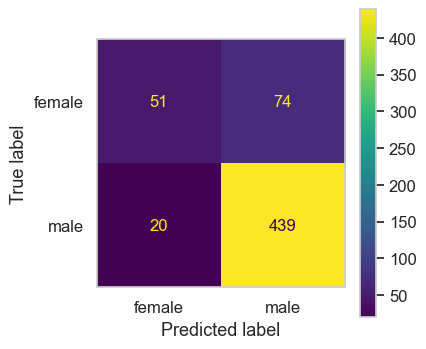

Accuracy: 0.834
Macro-F1: 0.704
Female — precision 0.695, recall 0.401, F1 0.509

Modèle : GradientBoosting


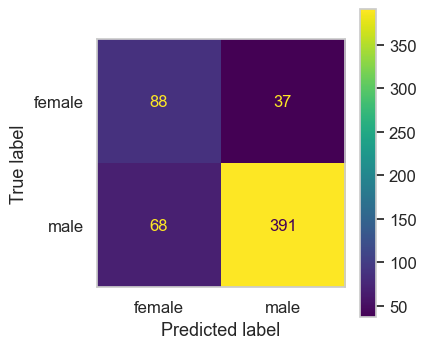

Accuracy: 0.823
Macro-F1: 0.757
Female — precision 0.573, recall 0.698, F1 0.629


,model,accuracy,macro_f1
0,LogisticRegression,0.739801,0.684856
1,RandomForest,0.833733,0.704275
2,GradientBoosting,0.823449,0.756685


In [ ]:
# Validation croisée (5-fold) – modèles pondérés (class_weight / sample_weight)
cv_results_char_w = run_cv_for_models(
    X_char, y,
    description="Personnages seuls",
    weighted=True,
    n_splits=5,
)
cv_results_char_w


Analyse de seuil – Personnages seuls (Gradient Boosting)
Seuil = 0.6



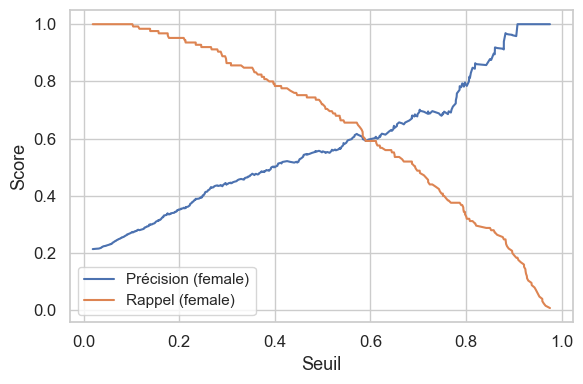

Accuracy globale : 0.829
Macro-F1         : 0.744

Classification report :

              precision    recall  f1-score   support

      female      0.602     0.592     0.597       125
        male      0.889     0.893     0.891       459

    accuracy                          0.829       584
   macro avg      0.745     0.743     0.744       584
weighted avg      0.828     0.829     0.828       584



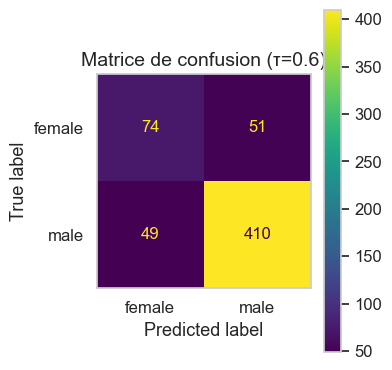

(GradientBoostingClassifier(random_state=42), SimpleImputer(), 0.8287671232876712, 0.744039270687237)


In [ ]:
# Analyse de seuil pour un modèle choisi
# (ici : Gradient Boosting pondéré sur X_char)
print(threshold_analysis(
    X_char,
    y,
    description="Personnages seuls (Gradient Boosting)",
    weighted=True,
    test_size=0.2,
    tau=0.6
))

# Partie 2 – Prédiction avec features personnages + métadonnées

Nous répétons la même procédure en utilisant cette fois toutes les variables :
features personnages **et** variables meta (année, canon, genre littéraire, etc.).


=== Personnages + meta ===

Modèle : LogisticRegression


C:\Users\arnod\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


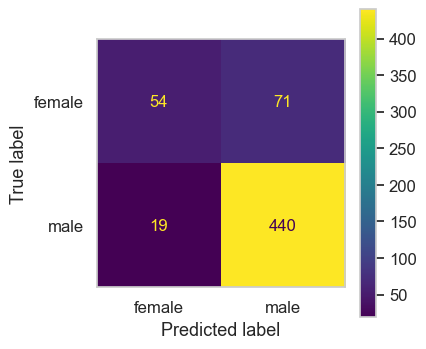

C:\Users\arnod\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.836
Macro-F1: 0.701
Female — precision 0.728, recall 0.380, F1 0.499

Modèle : RandomForest


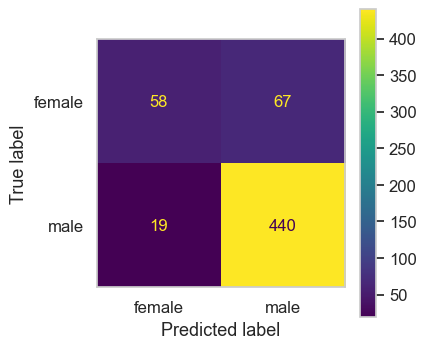

Accuracy: 0.844
Macro-F1: 0.724
Female — precision 0.731, recall 0.430, F1 0.541

Modèle : GradientBoosting


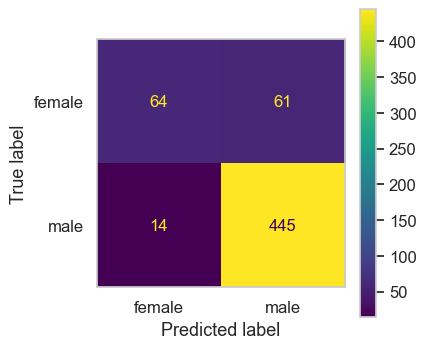

Accuracy: 0.856
Macro-F1: 0.756
Female — precision 0.747, recall 0.500, F1 0.599


,model,accuracy,macro_f1
0,LogisticRegression,0.836476,0.700875
1,RandomForest,0.843675,0.723516
2,GradientBoosting,0.856359,0.755775


In [ ]:
# Validation croisée (5-fold) – modèles NON pondérés (X_full)
cv_results_full_unw = run_cv_for_models(
    X_full, y,
    description="Personnages + meta",
    weighted=False,
    n_splits=5,
)
cv_results_full_unw


=== Personnages + meta ===

Modèle : LogisticRegression


C:\Users\arnod\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


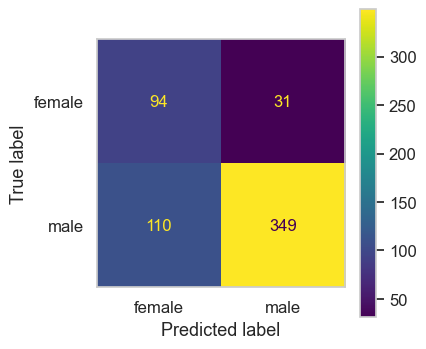

C:\Users\arnod\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\arnod\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable

Accuracy: 0.765
Macro-F1: 0.706
Female — precision 0.470, recall 0.738, F1 0.574

Modèle : RandomForest


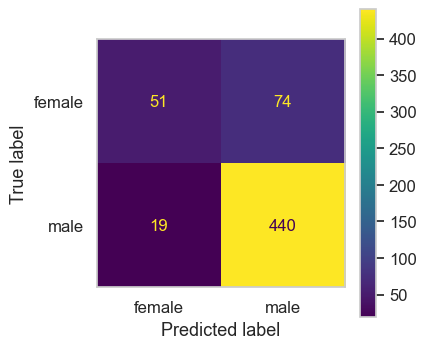

Accuracy: 0.837
Macro-F1: 0.710
Female — precision 0.707, recall 0.409, F1 0.518

Modèle : GradientBoosting


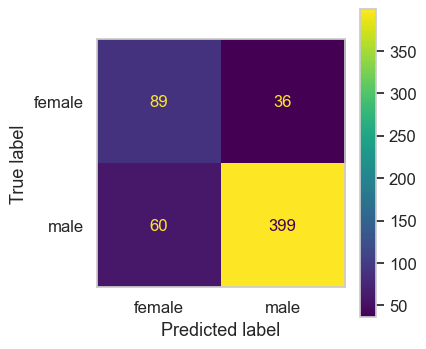

Accuracy: 0.830
Macro-F1: 0.769
Female — precision 0.583, recall 0.732, F1 0.649


,model,accuracy,macro_f1
0,LogisticRegression,0.764827,0.705754
1,RandomForest,0.836819,0.709997
2,GradientBoosting,0.830305,0.768635


In [ ]:
# Validation croisée (5-fold) – modèles pondérés (X_full)
cv_results_full_w = run_cv_for_models(
    X_full, y,
    description="Personnages + meta",
    weighted=True,
    n_splits=5,
)
cv_results_full_w


Analyse de seuil – Personnages + meta (Gradient Boosting)
Seuil = 0.6



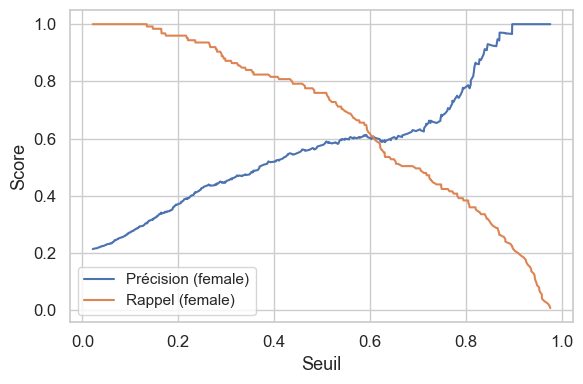

Accuracy globale : 0.830
Macro-F1         : 0.750

Classification report :

              precision    recall  f1-score   support

      female      0.602     0.616     0.609       125
        male      0.895     0.889     0.892       459

    accuracy                          0.830       584
   macro avg      0.748     0.752     0.750       584
weighted avg      0.832     0.830     0.831       584



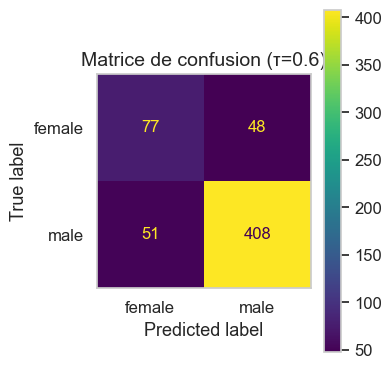

(GradientBoostingClassifier(random_state=42), SimpleImputer(), 0.8304794520547946, 0.7502494654312188)


In [ ]:
# Analyse de seuil pour un modèle choisi sur X_full
# (ici : Gradient Boosting pondéré)
print(threshold_analysis(
    X_full,
    y,
    description="Personnages + meta (Gradient Boosting)",
    weighted=True,
    test_size=0.2,
    tau=0.6
))

